# Исследовательский анализ данных (EDA) и сегментация клиентов E-Commerce

## Цель проекта:

Провести полный цикл первичного анализа данных: от проверки качества и подготовки данных до анализа продаж, товаров, географии и клиентской базы.
Отдельная часть проекта посвящена RFM-анализу, который используется для оценки активности и ценности клиентов.

## Ключевые бизнес-вопросы:

1. Как изменяется выручка интернет магазина во времени?
2. Какие товары формируют основную выручку?
3. Какова география продаж и средний чек по регионам?
4. Какие клиенты наиболее ценны для бизнеса и как распределяется клиентская база по RFM-сегментам?

In [1]:
#1. Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#2. Загружаем данные
data = pd.read_csv('data/data.csv', encoding='ISO-8859-1')

In [3]:
#3. Смотрим первые 5 строк
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
#4. Смотрим структуру и клюючевые сведения
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
#5. Размерность датасета
data.shape

(541909, 8)

In [6]:
#6. Проверка на наличие полных дубликатов
data.duplicated().sum() 

np.int64(5268)

## Полные дубликаты удалены, поскольку они не содержат доп.информации и могут искусственно увеличивать показатели продаж

In [7]:
#7. Удаление найденных дублей
data = data.drop_duplicates().reset_index(drop=True)

In [8]:
#8. Переводим в нужный тип данных столбцы InvoiceDate и CustomerID
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['CustomerID'] = data['CustomerID'].astype('Int64')

In [9]:
#9. Смотрим описательную статистику
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,536641.000000,536641,536641.000000,401604.0
mean,9.620029,2011-07-04 08:57:06.087421,4.632656,15281.160818
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.0
25%,1.000000,2011-03-28 10:52:00,1.250000,13939.0
50%,3.000000,2011-07-19 14:04:00,2.080000,15145.0
75%,10.000000,2011-10-18 17:05:00,4.130000,16784.0
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.0
std,219.130156,NaN,97.233118,1714.006089


In [10]:
#10. Посчитаем количество проблемных строк с аномалиями
print("Количество возвратов (Quantity < 0):", (data['Quantity'] < 0).sum())
print("Отрицательные цены (UnitPrice < 0):", (data['UnitPrice'] < 0).sum())
print("Нулевые цены (UnitPrice == 0):", (data['UnitPrice'] == 0).sum())

Количество возвратов (Quantity < 0): 10587
Отрицательные цены (UnitPrice < 0): 2
Нулевые цены (UnitPrice == 0): 2510


In [11]:
#11. Проверка остались ли "отмены" после фильтрации
data['InvoiceNo'].str.startswith('C').sum()

np.int64(9251)

In [12]:
#12. Проверяем количество и процент пропусков 
print('Пропуски:\n' ,data.isna().sum())
print('Процент пропусков:\n' ,data.isna().mean() * 100)

Пропуски:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64
Процент пропусков:
 InvoiceNo       0.000000
StockCode       0.000000
Description     0.270945
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     25.163377
Country         0.000000
dtype: float64


In [13]:
#13. Анализ возвратов
# 1. Кол-во возвратных транзакций
returns_df = data[data['Quantity'] < 0]
return_transactions = returns_df['InvoiceNo'].nunique()

# 2. Кол-во возвращенных единиц
returned_units = returns_df["Quantity"].abs().sum()
returned_units

# 3. Сумма возврата
refund_amount = (returns_df['Quantity'] * returns_df['UnitPrice']).sum()
refund_amount

np.float64(-893979.73)

## Анализ отмен и возвратов:

В исходных данных зафиксировано 5 172 возвратные транзакции на общую сумму 893 979.73 (всего возвращено 482 517 шт. товаров).

Так как возвратные операции представляют собой отмены заказа или корректировки, они исключаются из основного датасета  для объективного расчета ключевых бизнес-метрик.

In [14]:
#14. Фильтрация датасета по условию, где Quantity > 0 и UnitPrice > 0
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

In [15]:
#15. Приводим к нижнему регистру и удаляем лишние пробелы
data['Description'] = data['Description'].str.lower().str.strip()

In [16]:
#16. Создание нового столбца  
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

In [17]:
#17. Извлекаем год, месяц, день недели и час покупок
data['Year'] = data['InvoiceDate'].dt.year
data['Month'] = data['InvoiceDate'].dt.month
data['DayOfWeek'] = data['InvoiceDate'].dt.day_name()
data['Hour'] = data['InvoiceDate'].dt.hour


In [18]:
#18. Период данных начало и конец
data['InvoiceDate'].min() 
data['InvoiceDate'].max()

print(data['InvoiceDate'].min())
print(data['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [19]:
#19. Базовые KPI бизнеса
total_revenue = data['TotalPrice'].sum()
total_orders = data['InvoiceNo'].nunique()
total_customers = data['CustomerID'].nunique()
aov = total_revenue / total_orders

print(f"Общая выручка: £{total_revenue:,.2f}")
print(f"Всего заказов: {total_orders:,}")
print(f"Уникальных клиентов: {total_customers:,}")
print(f"Средний чек (AOV): £{aov:.2f}")

Общая выручка: £10,642,110.80
Всего заказов: 19,960
Уникальных клиентов: 4,338
Средний чек (AOV): £533.17


In [20]:
#20. Расчитываем помесячную динамику продаж 
monthly_sales = data.groupby(['Year','Month']).agg({
    'TotalPrice':'sum',
    'InvoiceNo':'nunique'}).reset_index()
monthly_sales

,Year,Month,TotalPrice,InvoiceNo
0,2010,12,821452.730,1559
1,2011,1,689811.610,1086
2,2011,2,522545.560,1100
3,2011,3,716215.260,1454
4,2011,4,536968.491,1246
5,2011,5,769296.610,1681
6,2011,6,760547.010,1533
7,2011,7,718076.121,1475
8,2011,8,757841.380,1361
9,2011,9,1056435.192,1837


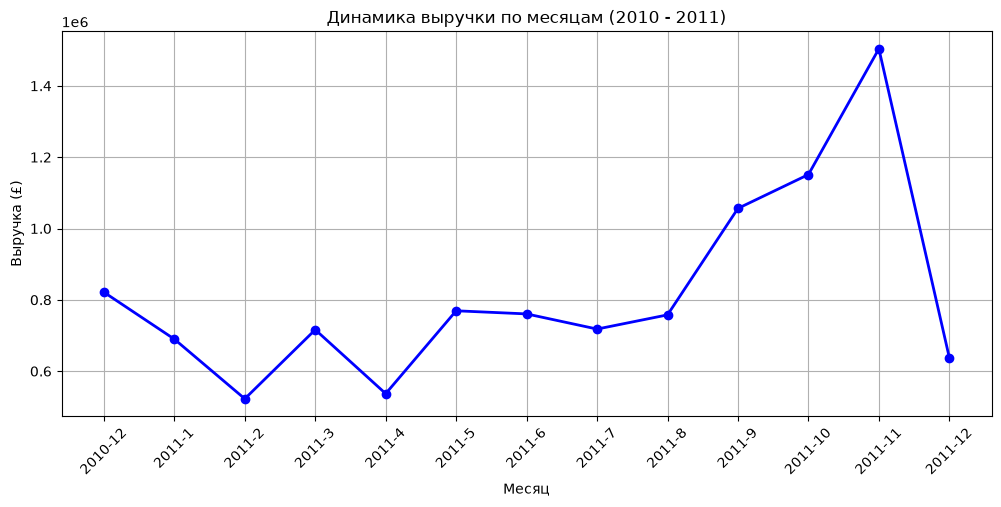

In [21]:
#21. Строим график продаж
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['TotalPrice'], marker='o', color='b', linewidth=2)
plt.title('Динамика выручки по месяцам (2010 - 2011)')
plt.xlabel('Месяц')
plt.ylabel('Выручка (£)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [22]:
#22. Анализ продаж по дням недели
weekly_sales = data.groupby(['DayOfWeek']).agg({
    'TotalPrice':'sum',
    'InvoiceNo':'nunique'}).reset_index()

weekly_sales

,DayOfWeek,TotalPrice,InvoiceNo
0,Friday,1837470.491,3140
1,Monday,1775782.071,3126
2,Sunday,806790.781,2204
3,Thursday,2199292.570,4246
4,Tuesday,2175700.511,3554
5,Wednesday,1847074.380,3690


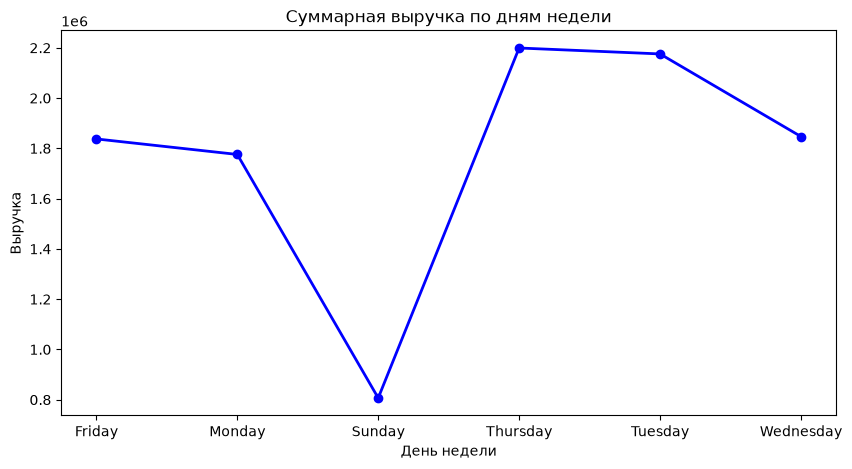

In [23]:
#23. График продаж по дням недели

plt.figure(figsize=(10, 5))
plt.title('Суммарная выручка по дням недели')
plt.plot(weekly_sales['DayOfWeek'], weekly_sales['TotalPrice'], marker='o', color='b', linewidth=2)
plt.xlabel('День недели')
plt.ylabel('Выручка')
plt.show()


### Выводы по анализу динамики продаж по дням недели

* **Пик покупательской активности (вторник и четверг):**
  * Наибольший объем выручки генерируют **четверг (Thursday)** и **вторник (Tuesday)**, достигая максимальных значений порядка **2,2 млн**.
  * **Среда (Wednesday)** и **пятница (Friday)** также демонстрируют стабильно высокие показатели продаж (около **1,8-1,85 млн**).

* **Минимальная активность (воскресенье):**
  * В **воскресенье (Sunday)** наблюдается резкий провал — выручка падает более чем в 2.5 раза по сравнению с четвергом (до **~0,8 млн**).

In [24]:
#24. Расчитываем помесячную динамику продаж по часам
count_order_hour = data.groupby(['Hour']).agg({
    'TotalPrice':'sum',
    'InvoiceNo':'nunique'}).reset_index()

count_order_hour

,Hour,TotalPrice,InvoiceNo
0,6,4.250,1
1,7,31059.210,29
2,8,283750.680,566
3,9,990054.991,1484
4,10,1444814.771,2361
5,11,1236573.290,2396
6,12,1439324.660,3220
7,13,1261195.200,2753
8,14,1177907.521,2457
9,15,1350333.310,2336


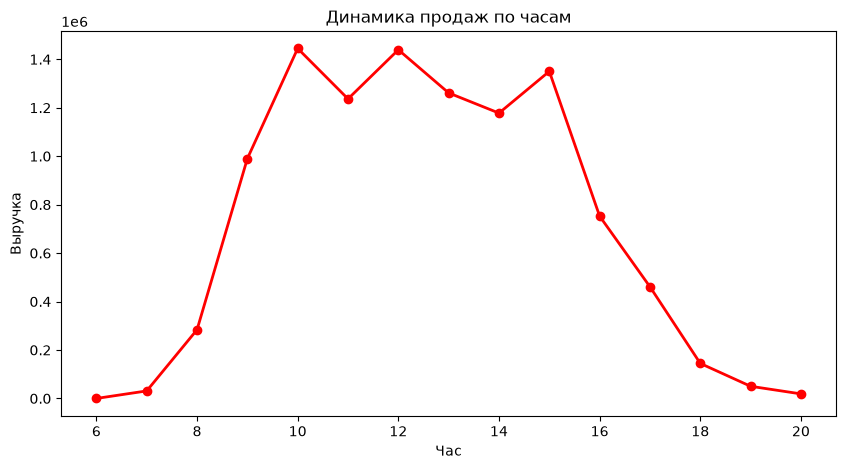

In [25]:
#25. График динамики продаж по часам

plt.figure(figsize=(10, 5))
plt.title('Динамика продаж по часам')
plt.plot(count_order_hour['Hour'], count_order_hour['TotalPrice'], marker='o', color='r', linewidth=2)
plt.xlabel('Час')
plt.ylabel('Выручка')
plt.show()

### Выводы по анализу динамики продаж по часам

* **Основное окно активности (10:00 – 15:00):**
  * Основной объем выручки формируется в дневное время с 10:00 до 15:00.
  * Пики продаж приходятся на **10:00** и **12:00** (достигая порядка **1,45 млн**), с небольшим локальным всплеском в **15:00** (около **1,35 млн**).

* **Утренний разгон и вечерний спад:**
  * С 6:00 до 8:00 продажи минимальны, после чего с 8:00 до 10:00 наблюдается стремительный рост активности.
  * После 15:00 происходит резкое снижение выручки, а к 18:00–20:00 продажи практически прекращаются (менее **0,2 млн**)[cite: 2].

In [26]:
#26. Анализ географии
country_sales = data.groupby('Country').agg({
    'TotalPrice': 'sum',
    'InvoiceNo': 'nunique'
}).sort_values(by='TotalPrice', ascending=False).reset_index()

country_sales.columns = ['Country', 'Revenue', 'Orders']

country_sales.head(10)

,Country,Revenue,Orders
0,United Kingdom,9001744.094,18019
1,Netherlands,285446.340,94
2,EIRE,283140.520,288
3,Germany,228678.400,457
4,France,209625.370,392
5,Australia,138453.810,57
6,Spain,61558.560,90
7,Switzerland,57067.600,54
8,Belgium,41196.340,98
9,Sweden,38367.830,36


In [27]:
#27. Расчет среднего чека по регионам
country_sales['AOV'] = country_sales['Revenue'] / country_sales['Orders']
country_sales

,Country,Revenue,Orders,AOV
0,United Kingdom,9001744.094,18019,499.569571
1,Netherlands,285446.340,94,3036.663191
2,EIRE,283140.520,288,983.126806
3,Germany,228678.400,457,500.390372
4,France,209625.370,392,534.758597
5,Australia,138453.810,57,2429.014211
6,Spain,61558.560,90,683.984000
7,Switzerland,57067.600,54,1056.807407
8,Belgium,41196.340,98,420.370816
9,Sweden,38367.830,36,1065.773056


In [28]:
#28. Смотрим, сколько уникальных значения в столбцах Description и StockCode
data['Description'].nunique()
data['StockCode'].nunique()

# Топ-10 товаров по выручке
clean_data = data[~data['Description'].isin(['manual', 'postage', 'dotcom postage'])]
top_products_rev = (clean_data.groupby("Description").agg({
    "TotalPrice": "sum",
    "Quantity": "sum",
    "InvoiceNo": "nunique"}).sort_values(by="TotalPrice", ascending=False).head(10))

# Доля Топ-10 товаров в общей выручке
# Примечание: доля рассчитана относительно выручки от товарных позиций, без учета сервисных позиций(manual, postage)

merchandise_revenue = clean_data['TotalPrice'].sum()
top10_share = (top_products_rev["TotalPrice"].sum() / merchandise_revenue) * 100

print(f"Доля Топ-10 товаров в общей выручке: {top10_share:.2f}%")
top_products_rev

Доля Топ-10 товаров в общей выручке: 9.43%


,TotalPrice,Quantity,InvoiceNo
Description,,,
regency cakestand 3 tier,174156.54,13851,1988
"paper craft , little birdie",168469.60,80995,1
white hanging heart t-light holder,106236.72,37872,2256
party bunting,99445.23,18283,1685
jumbo bag red retrospot,94159.81,48371,2089
medium ceramic top storage jar,81700.92,78033,247
rabbit night light,66870.03,30739,994
paper chain kit 50's christmas,64875.59,19329,1160
assorted colour bird ornament,58927.62,36362,1455


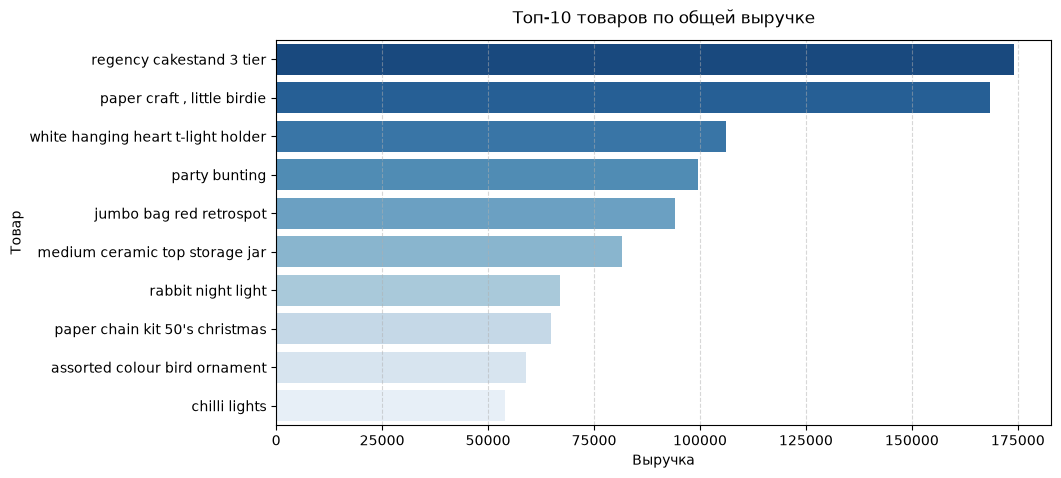

In [29]:
#29. График "Топ-10 товаров по общей выручке"
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_products_rev,
    x="TotalPrice",
    y="Description",
    palette="Blues_r",
    hue="Description",
    legend=False,
)
plt.title("Топ-10 товаров по общей выручке", fontsize=12, pad=12)
plt.xlabel("Выручка")
plt.ylabel("Товар")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

In [30]:
#30. Топ-10 товаров по количеству проданных единиц
top_10_quantity = clean_data.groupby('Description').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).sort_values(by='Quantity', ascending=False).reset_index().head(10)

top_10_quantity

,Description,Quantity,TotalPrice
0,"paper craft , little birdie",80995,168469.60
1,medium ceramic top storage jar,78033,81700.92
2,world war 2 gliders asstd designs,54951,13814.01
3,jumbo bag red retrospot,48371,94159.81
4,white hanging heart t-light holder,37872,106236.72
5,popcorn holder,36749,34288.67
6,pack of 72 retrospot cake cases,36396,21246.45
7,assorted colour bird ornament,36362,58927.62
8,rabbit night light,30739,66870.03
9,mini paint set vintage,26633,16937.82


### Выводы по анализу ТОП-10 товаров по количеству продаж

* **Лидеры по объему реализации:**
  * Самым продаваемым товаром стал **`paper craft , little birdie`** с результатом **80 995 шт.**, принесший максимальную выручку в размере **168 469,60**.
  * На втором месте находится **`medium ceramic top storage jar`** (**78 033 шт.** и **81 700,92** выручки).

* **Популярные категории товаров:**
  * **Товары для декора и праздника:** Высокий спрос наблюдается на сувениры и предметы интерьера (`world war 2 gliders asstd designs` — **54 951 шт.**, `white hanging heart t-light holder` — **37 872 шт.**, `assorted colour bird ornament` — **36 362 шт.**).
  * **Упаковка и сервировка:** Стабильно высокий объем продаж показывают товары для кухни и вечеринок (`jumbo bag red retrospot` — **48 371 шт.**, `popcorn holder` — **36 749 шт.**, `pack of 72 retrospot cake cases` — **36 396 шт.**).
  * **Детские товары и подарки:** В топ вошли ночники и наборы для творчества (`rabbit night light` — **30 739 шт.**, `mini paint set vintage` — **26 633 шт.**).

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: TotalPrice, dtype: float64


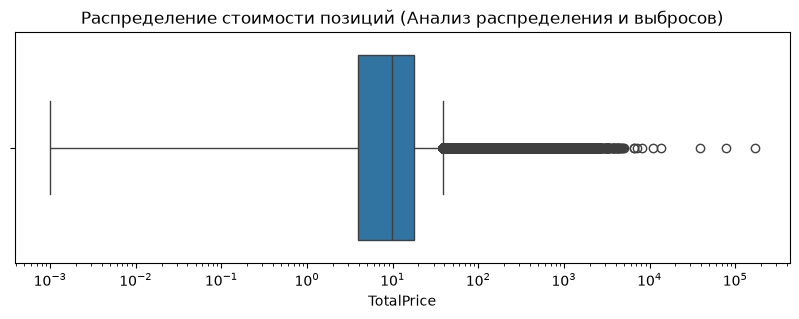

In [31]:
#31. Анализ выбросов
print(data['TotalPrice'].describe())

# Визуализация выбросов (Boxplot)
plt.figure(figsize=(10, 3))
sns.boxplot(x=data['TotalPrice'])
plt.title('Распределение стоимости позиций (Анализ распределения и выбросов)')
plt.xscale('log')
plt.show()

In [32]:
#32. RFM-анализ
max_date = data['InvoiceDate'].max()

customer_rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x:(max_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'}).reset_index()

customer_rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
customer_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


## RFM-анализ выполнен только для транзакций с известным CustomerID, поскольку операции без идентификатора клиента невозможно корректно связать с конретным покупателем

In [33]:
#33. RFM Scoring
customer_rfm['R_Score'] = pd.qcut(customer_rfm['Recency'], 4, labels=[4, 3, 2, 1])
customer_rfm['F_Score'] = pd.qcut(customer_rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
customer_rfm['M_Score'] = pd.qcut(customer_rfm['Monetary'], 4, labels=[1, 2, 3, 4])

customer_rfm['RFM_Segment'] = (customer_rfm['R_Score'].astype(str) + 
                               customer_rfm['F_Score'].astype(str) + 
                               customer_rfm['M_Score'].astype(str))
customer_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,12346,325,1,77183.60,1,1,4,114
1,12347,1,7,4310.00,4,4,4,444
2,12348,74,4,1797.24,2,3,4,234
3,12349,18,1,1757.55,3,1,4,314
4,12350,309,1,334.40,1,1,2,112


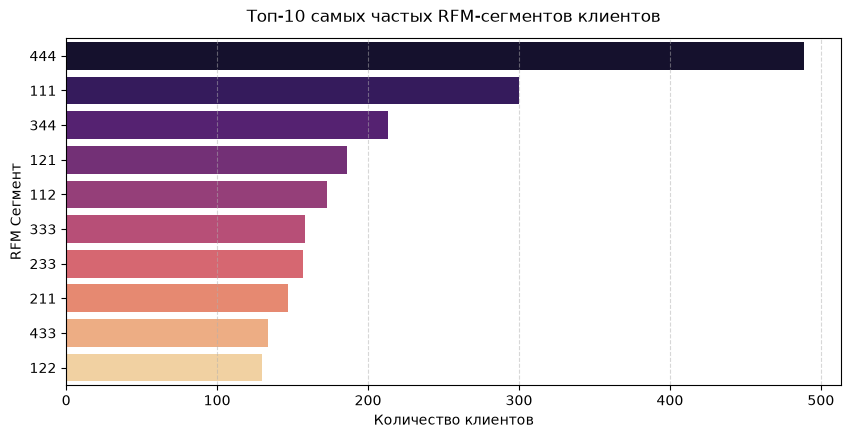

In [34]:
#34. График "Топ-10 RFM-сегментов"
top_segments = (
    customer_rfm["RFM_Segment"].value_counts().head(10).reset_index()
)
top_segments.columns = ["RFM_Segment", "Count"]

plt.figure(figsize=(10, 4.5))
sns.barplot(
    data=top_segments,
    x="Count",
    y="RFM_Segment",
    palette="magma",
    hue="RFM_Segment",
    legend=False,
)
plt.title("Топ-10 самых частых RFM-сегментов клиентов", fontsize=12, pad=12)
plt.xlabel("Количество клиентов")
plt.ylabel("RFM Сегмент")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

## Для сегментации клиенты разделены на 4 квантильные группы

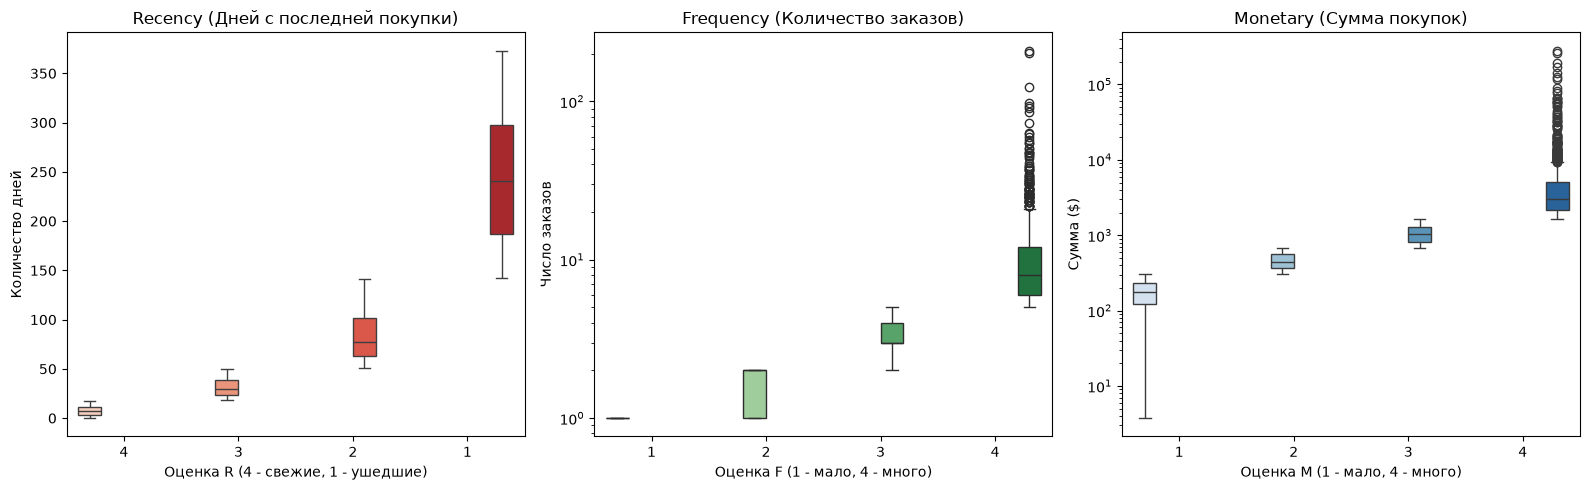

In [35]:
#35. График "Распределение оценок RFM"
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Recency (Дни)
sns.boxplot(
    data=customer_rfm,
    x="R_Score",
    y="Recency",
    ax=axes[0],
    palette="Reds",
    hue="R_Score",
    legend=False,
)
axes[0].set_title("Recency (Дней с последней покупки)")
axes[0].set_xlabel("Оценка R (4 - свежие, 1 - ушедшие)")
axes[0].set_ylabel("Количество дней")

# 2. Frequency (Количество покупок)
sns.boxplot(
    data=customer_rfm,
    x="F_Score",
    y="Frequency",
    ax=axes[1],
    palette="Greens",
    hue="F_Score",
    legend=False,
)
axes[1].set_title("Frequency (Количество заказов)")
axes[1].set_xlabel("Оценка F (1 - мало, 4 - много)")
axes[1].set_ylabel("Число заказов")
axes[1].set_yscale("log")  

# 3. Monetary (Выручка)
sns.boxplot(
    data=customer_rfm,
    x="M_Score",
    y="Monetary",
    ax=axes[2],
    palette="Blues",
    hue="M_Score",
    legend=False,
)
axes[2].set_title("Monetary (Сумма покупок)")
axes[2].set_xlabel("Оценка M (1 - мало, 4 - много)")
axes[2].set_ylabel("Сумма ($)")
axes[2].set_yscale("log")  

plt.tight_layout()

plt.show()

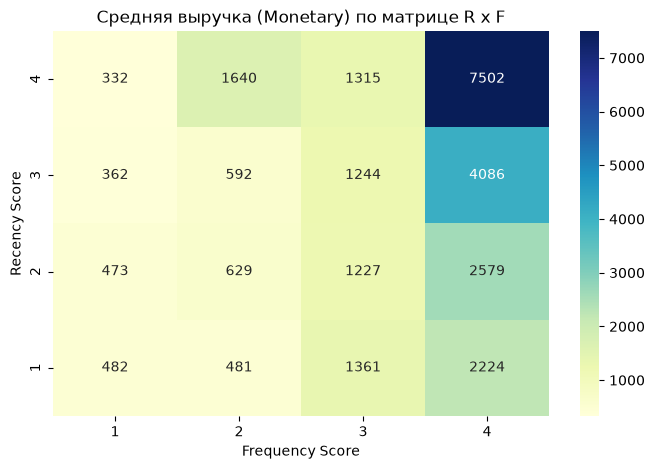

In [36]:
#36. Тепловая карта показателей Monetary для RFM-матрицы
rfm_monetary_pivot = customer_rfm.pivot_table(
    index="R_Score", columns="F_Score", values="Monetary", aggfunc="mean"
)

plt.figure(figsize=(8, 5))
sns.heatmap(rfm_monetary_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Средняя выручка (Monetary) по матрице R x F")
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")
plt.show()

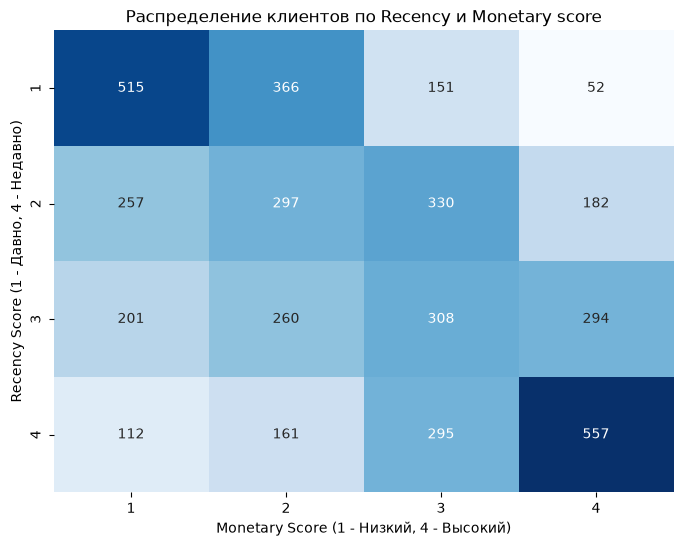

In [37]:
#37. Визуализация тепловой карты сегментов
customer_rfm['R_Score'] = customer_rfm['R_Score'].astype(int)
customer_rfm['M_Score'] = customer_rfm['M_Score'].astype(int)

rfm_pivot = customer_rfm.pivot_table(
    index='R_Score', 
    columns='M_Score', 
    values='CustomerID', 
    aggfunc='count'
).fillna(0) 

rfm_pivot = rfm_pivot.astype(float)


plt.figure(figsize=(8, 6))
sns.heatmap(rfm_pivot, annot=True, fmt='.0f', cmap='Blues', cbar=False)

plt.title('Распределение клиентов по Recency и Monetary score')
plt.xlabel('Monetary Score (1 - Низкий, 4 - Высокий)')
plt.ylabel('Recency Score (1 - Давно, 4 - Недавно)')
plt.show()

In [38]:
#38. Сохраняем обработанные данные

# Сохраняем RFM-анализ
customer_rfm.to_csv('rfm_segmentation_results.csv', index=False)
# Сохраняем очищеный датасет
data.to_csv('cleaned_ecommerce_data.csv', index=False)